In [ ]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt


# Check for GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
else:
    print("⚠️ No GPU found. Running on CPU.")


# Dataset Paths

TRAIN_PATH = r"C:\Users\abhin\Downloads\New Plant Diseases Dataset(Augmented)\PlantVillage\train"
VAL_PATH   = r"C:\Users\abhin\Downloads\New Plant Diseases Dataset(Augmented)\PlantVillage\val"


# Transformations (Data Augmentation)

train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


# Load Datasets

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print("✅ Number of classes:", num_classes)


# Define CNN Model

class PlantCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = PlantCNN(num_classes).to(device)
print(model)


# Loss and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop

epochs = 15
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.2f}%")


# Visualize Some Training Images

import numpy as np




✅ Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 4GB Laptop GPU
CUDA Version: 12.4
✅ Number of classes: 38
PlantCNN(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=65536, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.5, inplace=False)
    (10): Linear(in_features=128, out_features=38, bias=True)
  )
)
Epoch [1/15] Train Loss: 1.7772 | Train Acc: 50.15% | Val Loss: 1.1114 | Val Acc: 64.90%
Epoch [2/15] Train Loss: 1.1694 | Train Acc: 64.55% | Val Loss: 0.6926 | Val Acc: 78.20%
Epoch [3/15] Train Loss: 1.0212 | Train Acc: 68.73% | Val Loss: 0.6285 | Val Acc: 80.22%
Epoch [4/15

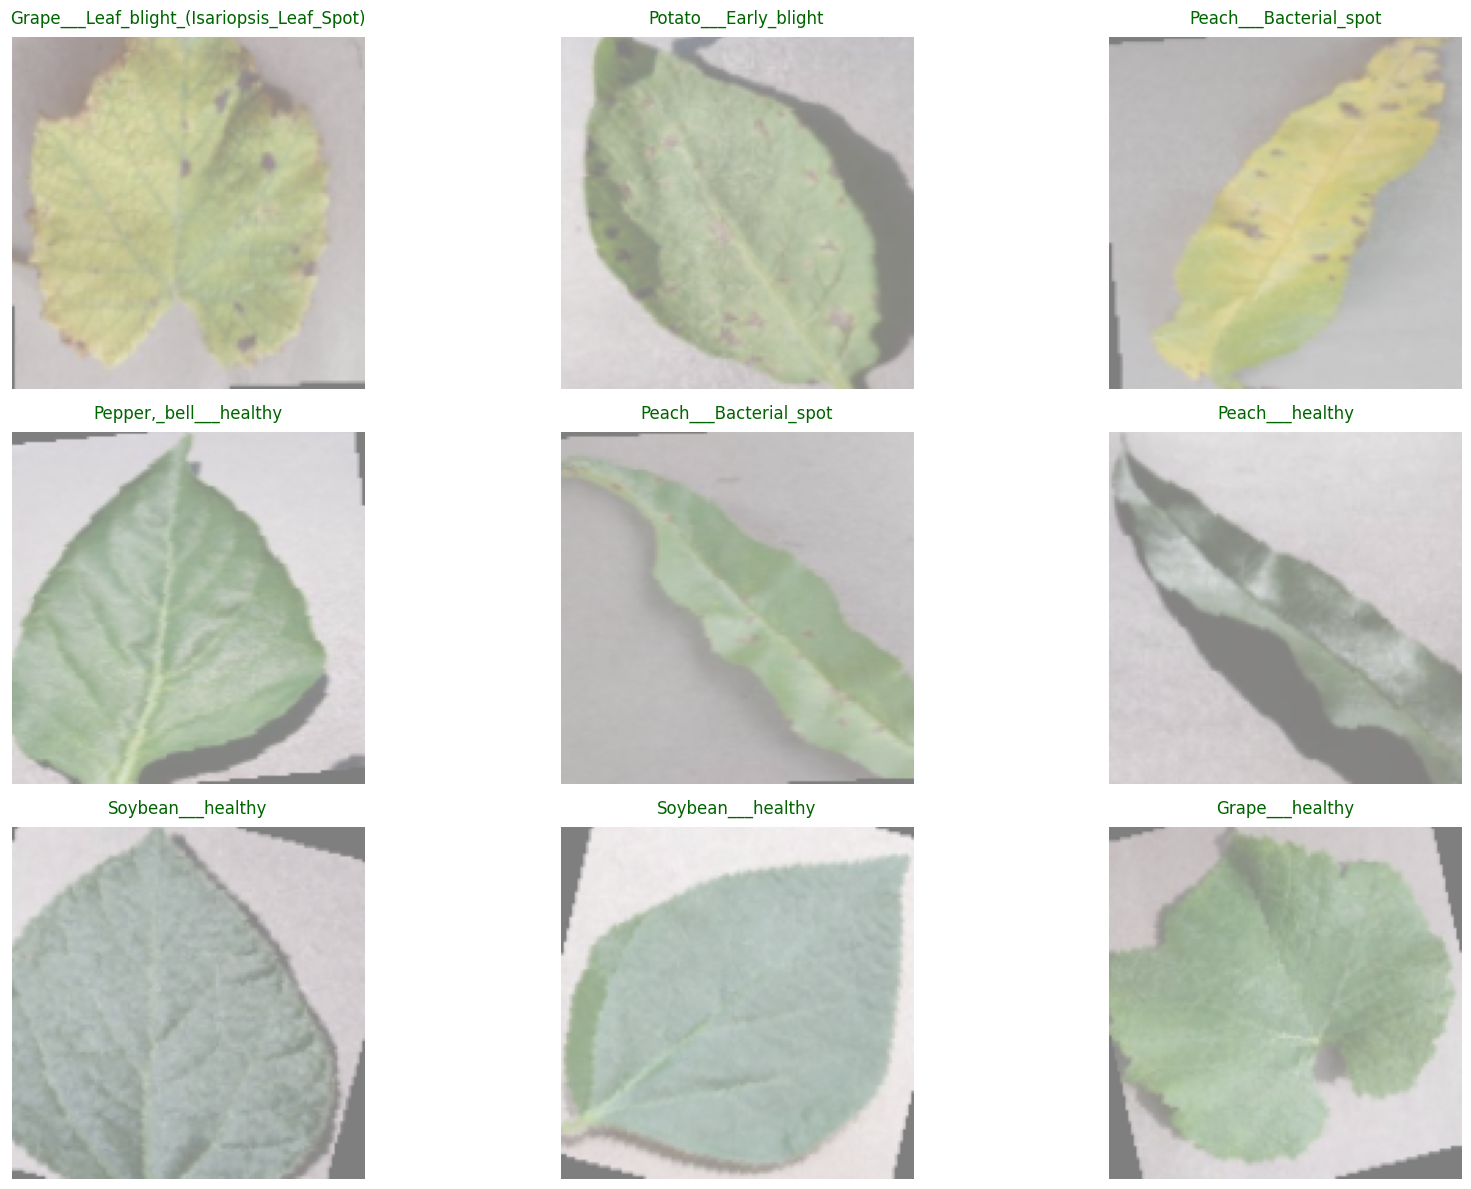

In [12]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Function to show a grid of images
def imshow_with_labels(images, labels, class_names, nrow=3, figsize=(15, 10)):
    # Unnormalize (if normalized)
    images = images / 2 + 0.5  
    np_images = images.numpy()
    
    batch_size = images.size(0)
    fig, axes = plt.subplots(nrows=(batch_size + nrow - 1)//nrow, ncols=nrow, figsize=figsize)
    axes = axes.flatten()
    
    for i in range(batch_size):
        img = np.transpose(np_images[i], (1, 2, 0))  # (C, H, W) → (H, W, C)
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=12, color='darkgreen', pad=10)
        axes[i].axis('off')
    
    # Hide unused axes (if total < grid size)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Select how many to display (say first 9)
images = images[:9]
labels = labels[:9]

# Show larger and clearer images with class names
imshow_with_labels(images, labels, train_dataset.classes, nrow=3, figsize=(18, 12))
